In [1]:
# Import libraries
import pandas as pd
import numpy as np
import nfl_data_py as nfl
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Create a range for nfl seasons
seasons = range(2018, 2022 + 1)

In [3]:
# Import play by play data from the nfl library
pbp_py = nfl.import_pbp_data(seasons)

2018 done.
2019 done.
2020 done.
2021 done.
2022 done.
Downcasting floats.


In [4]:
# Filter data for passing plays in the regular season
pbp_py_pass = pbp_py\
    .query("season_type == 'REG' & " +
           "play_type == 'pass' & air_yards.notnull()").reset_index()

In [5]:
# Filter data for rushing plays in the regular season
pbp_py_run = pbp_py\
    .query("season_type == 'REG' & " +
           "play_type == 'run' & rushing_yards.notnull()").reset_index()

In [6]:
# Aggregate Expected Points Added data
pbp_pass_epa = pbp_py_pass\
    .groupby(["posteam", "season"])\
    .agg({"epa": ["mean"]})

pbp_run_epa = pbp_py_run\
    .groupby(["posteam", "season"])\
    .agg({"epa": ["mean"]})

In [7]:
# Preview epa data for passing and rushing
print(pbp_pass_epa.head())

print(pbp_run_epa.head())

                     epa
                    mean
posteam season          
ARI     2018   -0.152257
        2019    0.108934
        2020    0.123427
        2021    0.245659
        2022   -0.018878
                     epa
                    mean
posteam season          
ARI     2018   -0.158909
        2019    0.038256
        2020    0.074084
        2021    0.011337
        2022   -0.019919


In [8]:
# Collapse the columns
pbp_pass_epa.columns = list(map("_".join, pbp_pass_epa.columns))

pbp_run_epa.columns = list(map("_".join, pbp_run_epa.columns))

In [9]:
# Rename columns so that they're easier to read and understand
pbp_pass_epa.rename(columns={"epa_mean": "passing_epa"},
                    inplace=True)

pbp_run_epa.rename(columns={"epa_mean": "rushing_epa"},
                    inplace=True)

In [10]:
# Reset index for team names and seasons columns
pbp_pass_epa.reset_index(inplace=True)

pbp_run_epa.reset_index(inplace=True)

In [11]:
pbp_pass_epa.head()

,posteam,season,passing_epa
0,ARI,2018,-0.152257
1,ARI,2019,0.108934
2,ARI,2020,0.123427
3,ARI,2021,0.245659
4,ARI,2022,-0.018878


In [12]:
# Combine passing epa and rushing epa data
pbp_team_epa = pbp_pass_epa.merge(
    pbp_run_epa,
    how="inner",
    on=["posteam", "season"])

In [13]:
# Query the 2022 NFL season (The most recent season available)
pbp_team_epa_2022 = pbp_team_epa.query("season == 2022")

In [37]:
# Display that the stats have been successfully merged together
pbp_team_epa_2022.head()

,posteam,season,passing_epa,rushing_epa
4,ARI,2022,-0.018878,-0.019919
9,ATL,2022,0.116395,0.030456
14,BAL,2022,0.045157,0.070075
19,BUF,2022,0.239749,0.083773
24,CAR,2022,0.022150,0.031281


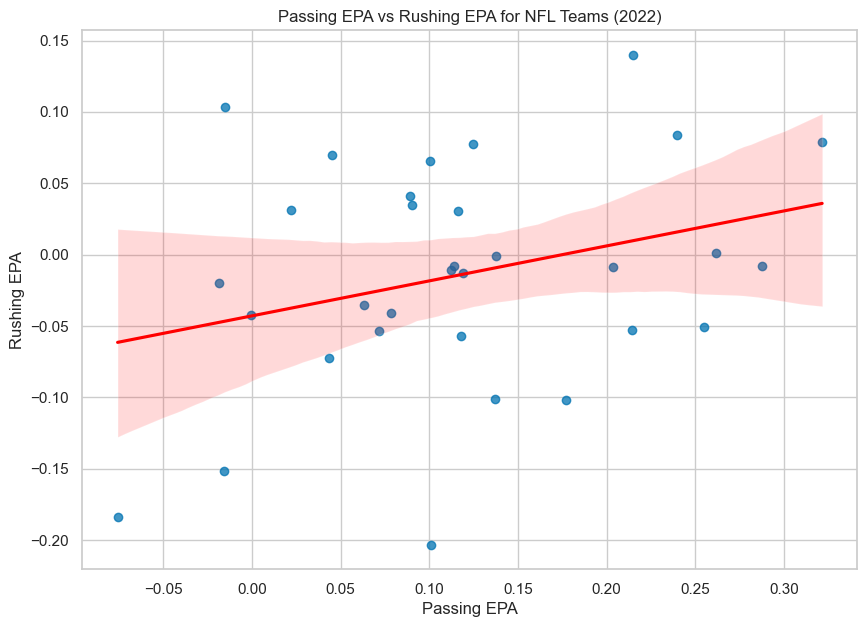

In [35]:
#Plot the EPA data
sns.set_theme(style="whitegrid", palette="colorblind")

fig, ax = plt.subplots(figsize=(10, 7))
epa_plot = sns.regplot(data=pbp_team_epa_2022,
            x="passing_epa",
            y="rushing_epa",
            scatter_kws={"alpha": 0.75},
            line_kws={"color": "red"},
            ax=ax);
plt.title("Passing EPA vs Rushing EPA for NFL Teams (2022)")
plt.xlabel("Passing EPA")
plt.ylabel("Rushing EPA")
plt.show()

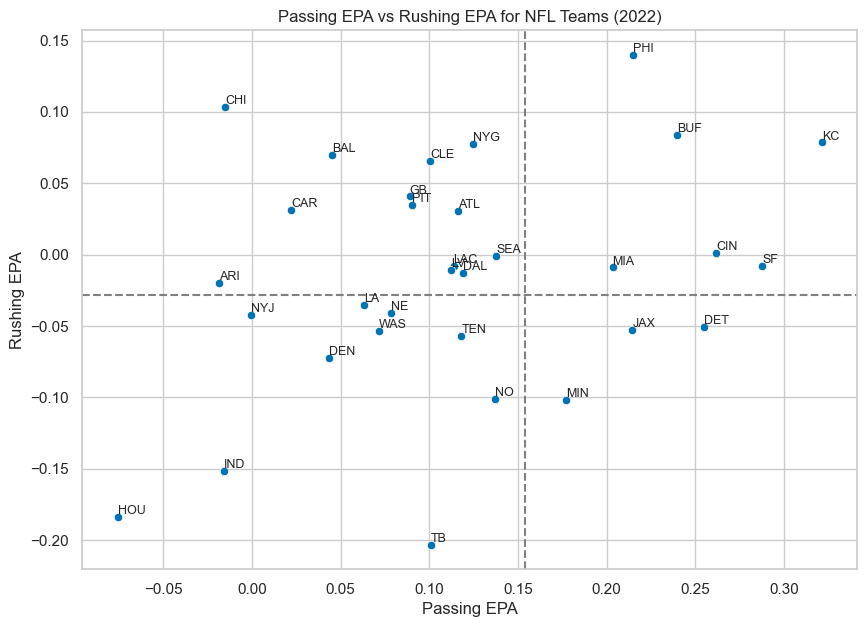

In [36]:
# Plot the data with team abbreviations
fig, ax = plt.subplots(figsize=(10, 7))


sns.scatterplot(
    data=pbp_team_epa_2022,
    x="passing_epa",
    y="rushing_epa",
    ax=ax
)

# Add team labels
for _, row in pbp_team_epa_2022.iterrows():
    ax.text(
        row["passing_epa"],
        row["rushing_epa"],
        row["posteam"],  
        fontsize=9,
        ha='left',   
        va='bottom' 
    )
# Draw quadrant lines using averages for rushing EPA and passing EPA
ax.axhline(-0.027900, linestyle='--', color='gray') 
ax.axvline(0.154185, linestyle='--', color='gray')

ax.set_title("Passing EPA vs Rushing EPA for NFL Teams (2022)")
ax.set_xlabel("Passing EPA")
ax.set_ylabel("Rushing EPA")

plt.show()

In [17]:
# Calculate the correlation coefficient
print(
    pbp_team_epa_2022[["rushing_epa", "passing_epa"]].corr()
)

             rushing_epa  passing_epa
rushing_epa     1.000000     0.296578
passing_epa     0.296578     1.000000
